## Damped Harmonic Oscillator in Homogeneous Medium

In [52]:
#Importing Required libraries
import numpy as np 
import matplotlib.pyplot as plt 

### Defining RK4 and Crank Nicolson Method

In [53]:
#Runge-Kutta 4th order method for solving ODEs
def rk4(f, x0, y0, h, n):

    x = x0
    y = np.array(y0)

    x_values = [x0]
    y_values = [y0]

    for i in range(n):
        k1 = f(x, y)
        k2 = f(x + h/2, y + (h/2)*k1)
        k3 = f(x + h/2, y + (h/2)*k2)
        k4 = f(x + h, y + h*k3)

        y = y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
        x = x + h

        x_values.append(x)
        y_values.append(y.copy())

    return np.array(x_values), np.array(y_values)

### System and Parameters

In [54]:
#parameters
m = 1
c = 1
k = 20
y0 = [1.0, 0.0]   #starts at position=1, velocity=0
t0 = 0.0           #start time
h  = 0.1           #step size
n  = 200           #number of steps → runs until t=20

#the function that defines the system of ODEs for the damped harmonic oscillator
def f(t, y):
    y1 = y[0]    #position
    y2 = y[1]    #velocity

    dy1 = y2
    dy2 = -(c/m)*y2 - (k/m)*y1

    return np.array([dy1, dy2])

In [55]:
t, y = rk4(f, t0, y0, h, n)

#Extract position and velocity
position = y[:, 0]
velocity = y[:, 1]

#Acceleration
acceleration = -(c/m)*velocity - (k/m)*position

#Energies
KE = 0.5 * m * velocity**2
PE = 0.5 * k * position**2
Total_E = KE + PE

#Forces
F_damping = -c * velocity
F_spring = -k * position
F_total = m * acceleration

## Underdamped Harmonic Oscillator

In [61]:
#Analytical solution for underdamped case
omega_d = np.sqrt(79)/2
def x_analytical(t):
    return np.exp(-t/2) * (np.cos(omega_d*t) + (1/omega_d)*np.sin(omega_d*t))

#----------------------------------------------------------------------------
#Analytical solution for critically damped case
gamma = c/(2*m)
def x_analytical(t):
    return (1 + gamma*t) * np.exp(-gamma*t)

#----------------------------------------------------------------------------
#Analytical solution for overdamped case
discriminant = np.sqrt(c**2 - 4*m*k)
r1 = (-c + discriminant) / (2*m)
r2 = (-c - discriminant) / (2*m)
# constants from initial conditions
# x(0)=1, v(0)=0
A = (r2)/(r2 - r1)
B = (-r1)/(r2 - r1)
def x_analytical(t):
    return A*np.exp(r1*t) + B*np.exp(r2*t)
#----------------------------------------------------------------------------

#plotting all the results
def plot_results(type):
    
    fig, ax = plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle(f"{type} Harmonic Oscillator Analysis", fontsize=16)

    #1) Position, Velocity, Acceleration
    ax[0,0].plot(t, position, label="Position")
    ax[0,0].plot(t, velocity, label="Velocity")
    ax[0,0].plot(t, acceleration, label="Acceleration")

    ax[0,0].set_xlabel("Time")
    ax[0,0].set_ylabel("Values")
    ax[0,0].set_title("Motion Quantities")
    ax[0,0].legend()
    ax[0,0].grid()

    #2) Energies
    ax[0, 1].plot(t, KE, label="Kinetic Energy")
    ax[0, 1].plot(t, PE, label="Potential Energy")
    ax[0, 1].plot(t, Total_E, label="Total Energy")

    ax[0,1].set_xlabel("Time")
    ax[0,1].set_ylabel("Energy")
    ax[0,1].set_title("Energy Decay (Damped System)")
    ax[0,1].legend()
    ax[0,1].grid()

    #3) Forces
    ax[0,2].plot(t, F_spring, label="Spring Force", linestyle="--")
    ax[0,2].plot(t, F_damping, label="Damping Force")
    ax[0,2].plot(t, F_total, label="Total Force")

    ax[0,2].set_xlabel("Time")
    ax[0,2].set_ylabel("Force")
    ax[0,2].set_title("Forces in System")
    ax[0,2].legend()
    ax[0,2].grid()

    #4) Phase Plot
    ax[1,0].plot(position, velocity)
    ax[1,0].set_xlabel("Position")
    ax[1,0].set_ylabel("Velocity")
    ax[1,0].set_title("Phase Space")
    ax[1,0].grid()

    #compare numerical vs analytical
    x_exact = x_analytical(t)

    ax[1,1].plot(t, position, label="RK4 Solution")
    ax[1,1].plot(t, x_exact, '--', label="Analytical Solution")

    ax[1,1].set_xlabel("Time")
    ax[1,1].set_ylabel("Position")
    ax[1,1].set_title("RK4 vs Analytical")
    ax[1,1].legend()
    ax[1,1].grid()

    #error analysis
    error = np.abs(position - x_exact)
    ax[1,2].plot(t, error)
    ax[1,2].set_xlabel("Time")
    ax[1,2].set_ylabel("Error")
    ax[1,2].set_title("Error vs Time (RK4)")
    ax[1,2].grid()

    plt.tight_layout()
    plt.show()
    print("Maximum error:", np.max(error))

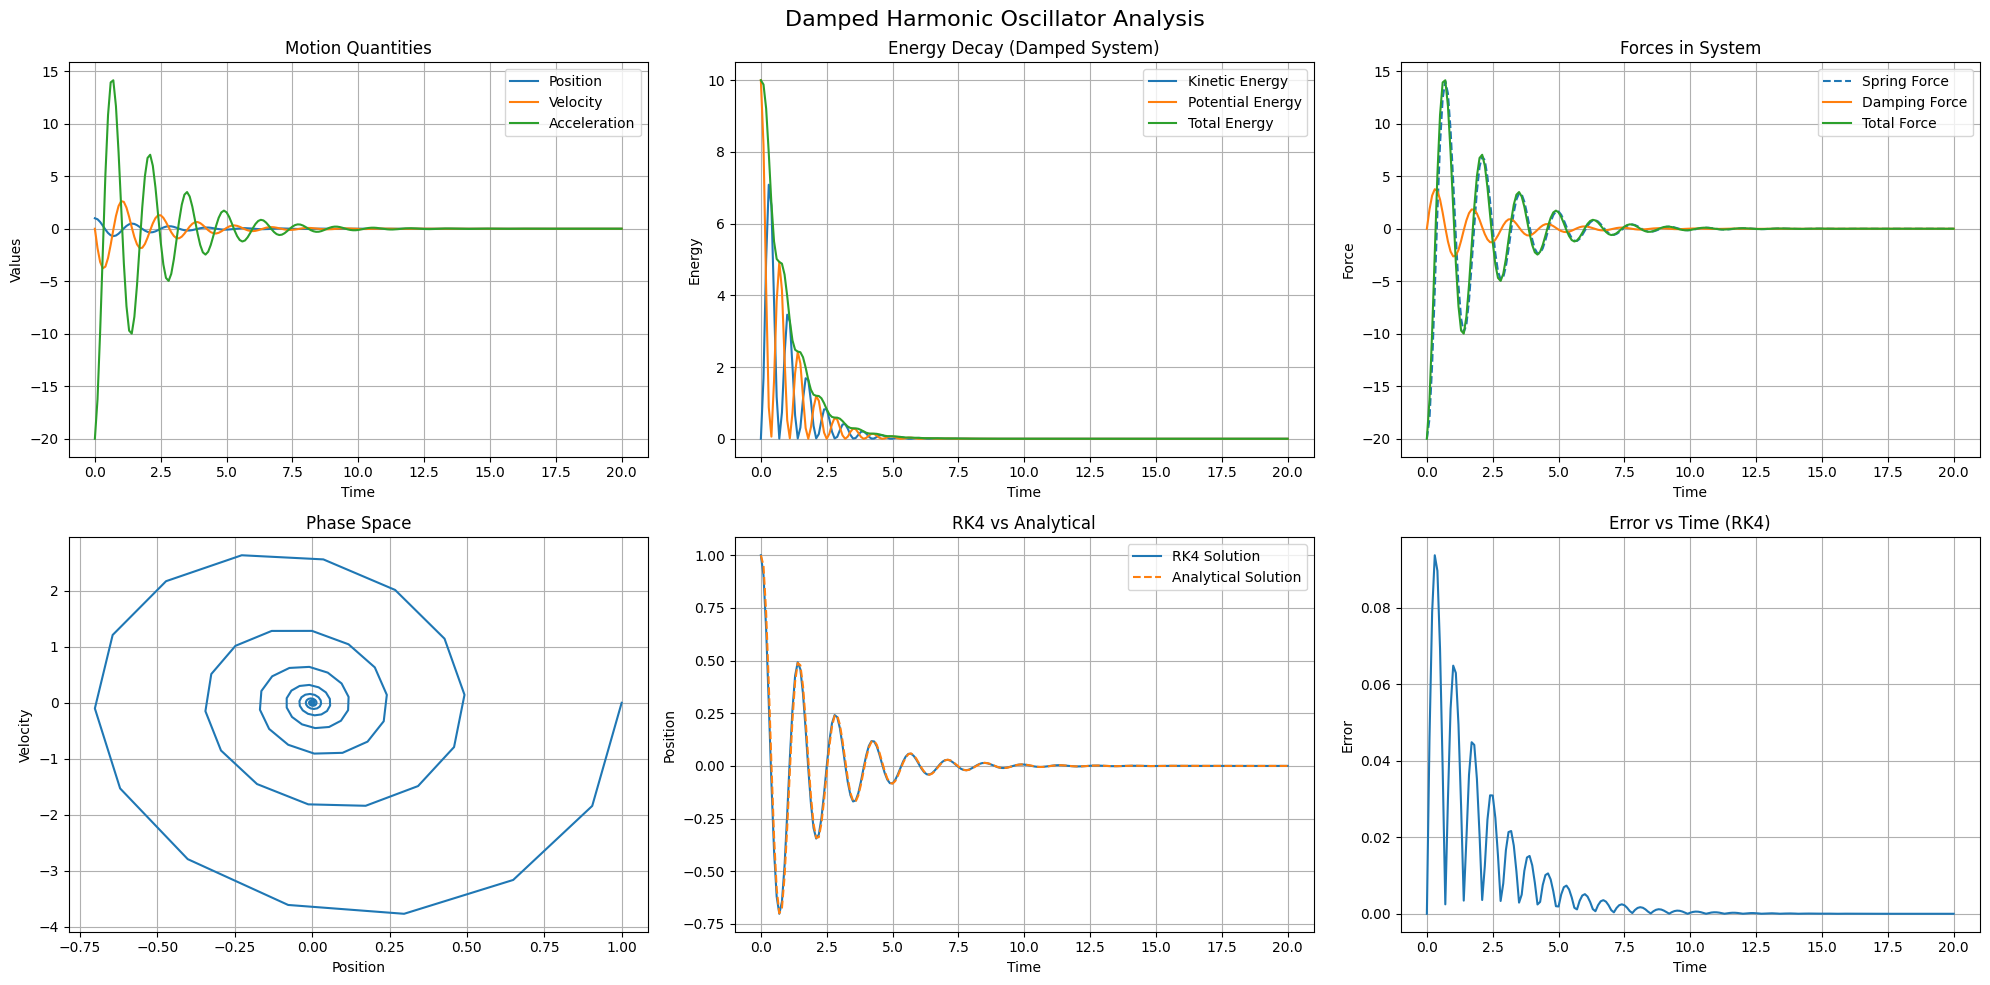

Maximum error: 0.0937194904582418


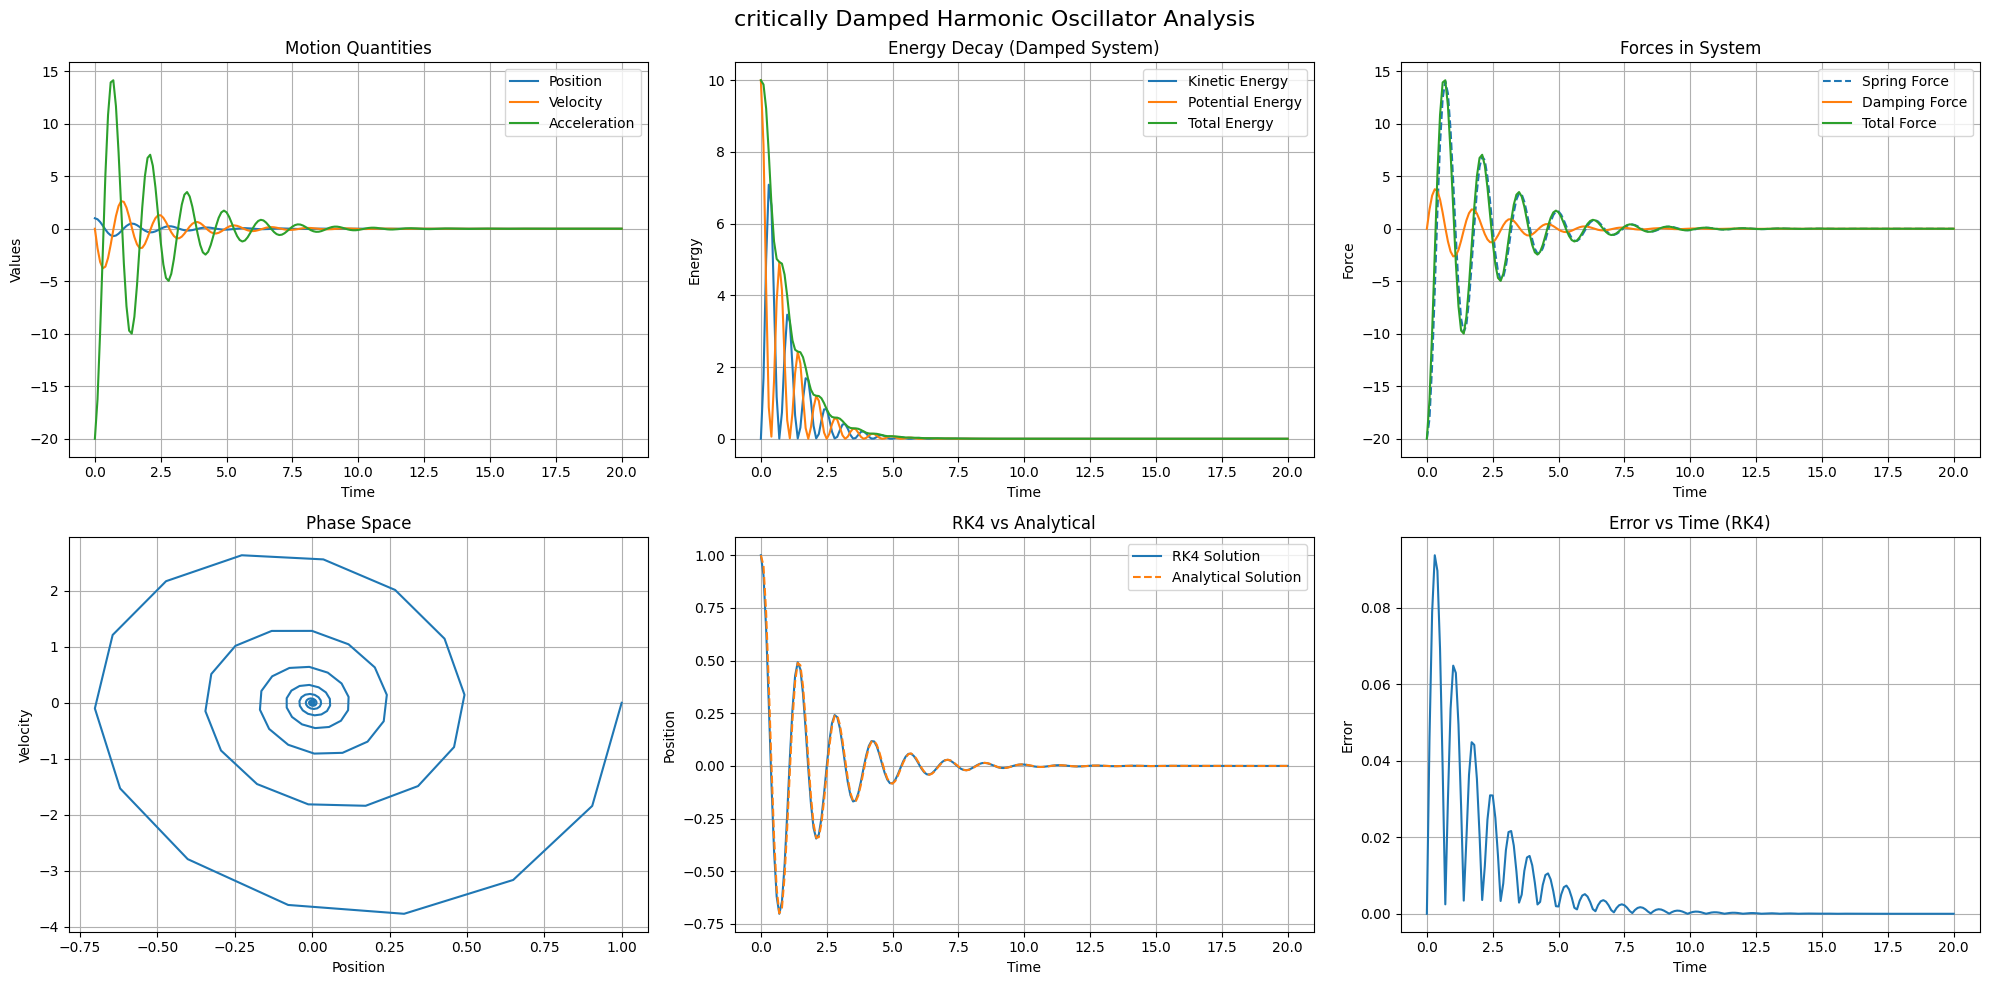

Maximum error: 0.0937194904582418


In [ ]:
plot_results("Damped")

# Critical damping condition
m = 1
k = 20
c = 2*np.sqrt(m*k)

#overdamped case
m = 1
k = 20
c = 12   # overdamped condition



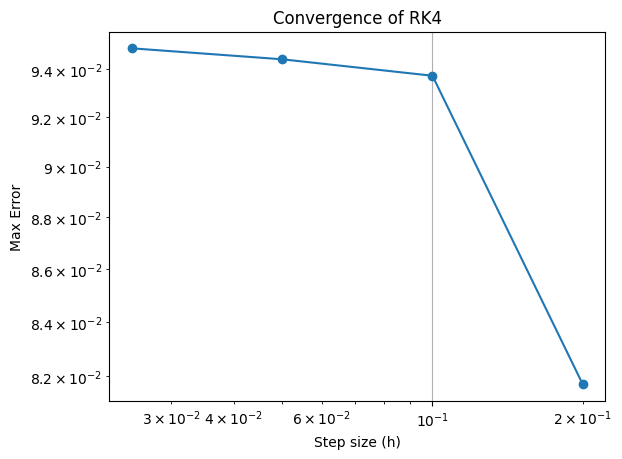

In [58]:
#convergemce test
h_values = [0.2, 0.1, 0.05, 0.025]
errors = []

for h_test in h_values:
    n_test = int(20 / h_test)
    t_test, y_test = rk4(f, t0, y0, h_test, n_test)

    pos_test = y_test[:, 0]
    x_exact_test = x_analytical(t_test)

    err = np.max(np.abs(pos_test - x_exact_test))
    errors.append(err)

plt.figure()
plt.loglog(h_values, errors, marker='o')
plt.xlabel("Step size (h)")
plt.ylabel("Max Error")
plt.title("Convergence of RK4")
plt.grid()
plt.show()